In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

proj = pd.read_csv("../data/projections.csv")
esp = proj[proj["abbr"] == "ESP"].copy()
esp["total_xpts"] = esp["1_Pts"] + esp["2_Pts"] + esp["3_Pts"]
esp["xpts_per_90_r1"] = esp["1_Pts"] / esp["1_xMins"] * 90

POS_COLORS = {"GK": "#f4a261", "DEF": "#2a9d8f", "MID": "#457b9d", "FWD": "#e63946"}
esp["color"] = esp["position"].map(POS_COLORS)

esp

,id,player,position,price,team,abbr,1_Pts,1_xMins,1_xG,1_xA,...,3_xG,3_xA,3_GoalPts,3_AssistPts,3_CSPts,3_ConcededPts,3_AppPts,total_xpts,xpts_per_90_r1,color
887,1081,Yéremy Pino,MID,5.9,Spain,ESP,1.08,5.0,0.009142,0.007411,...,0.004510,0.003656,0.027061,0.010968,0.000000,0.000000,1,3.19,19.440000,#457b9d
888,1082,Álex Baena,MID,6.0,Spain,ESP,1.11,5.0,0.011486,0.013191,...,0.005667,0.006508,0.034000,0.019523,0.000000,0.000000,1,3.27,19.980000,#457b9d
889,1084,Martín Zubimendi,MID,6.1,Spain,ESP,1.30,15.0,0.045710,0.007411,...,0.022551,0.003656,0.135303,0.010968,0.000000,0.000000,1,3.74,7.800000,#457b9d
890,1085,Pedro Porro,DEF,5.5,Spain,ESP,1.10,30.0,0.018284,0.029644,...,0.009020,0.014625,0.063141,0.043874,0.000000,-0.361857,1,2.94,3.300000,#2a9d8f
891,1086,Aymeric Laporte,DEF,5.5,Spain,ESP,5.00,80.0,0.000000,0.049661,...,0.000000,0.024500,0.000000,0.073499,1.857055,-0.361857,2,13.54,5.625000,#2a9d8f
892,1087,Alejandro Grimaldo,DEF,4.9,Spain,ESP,1.89,20.0,0.110907,0.077506,...,0.054715,0.038237,0.383002,0.114710,0.000000,-0.361857,1,4.89,8.505000,#2a9d8f
893,1088,Marc Cucurella,DEF,5.1,Spain,ESP,5.71,80.0,0.048758,0.171277,...,0.024054,0.084497,0.168377,0.253492,1.857055,-0.361857,2,15.29,6.423750,#2a9d8f
894,1089,Pau Cubarsí,DEF,5.0,Spain,ESP,5.18,80.0,0.045946,0.000000,...,0.022667,0.000000,0.158667,0.000000,1.857055,-0.361857,2,13.97,5.827500,#2a9d8f
895,1092,Lamine Yamal,MID,10.0,Spain,ESP,10.11,80.0,0.980175,0.546276,...,0.483556,0.269497,2.901333,0.808492,0.371411,0.000000,2,26.08,11.373750,#457b9d
896,1093,Ferran Torres,FWD,7.8,Spain,ESP,2.85,25.0,0.349379,0.034918,...,0.172361,0.017226,0.861805,0.051679,0.000000,0.000000,1,7.56,10.260000,#e63946


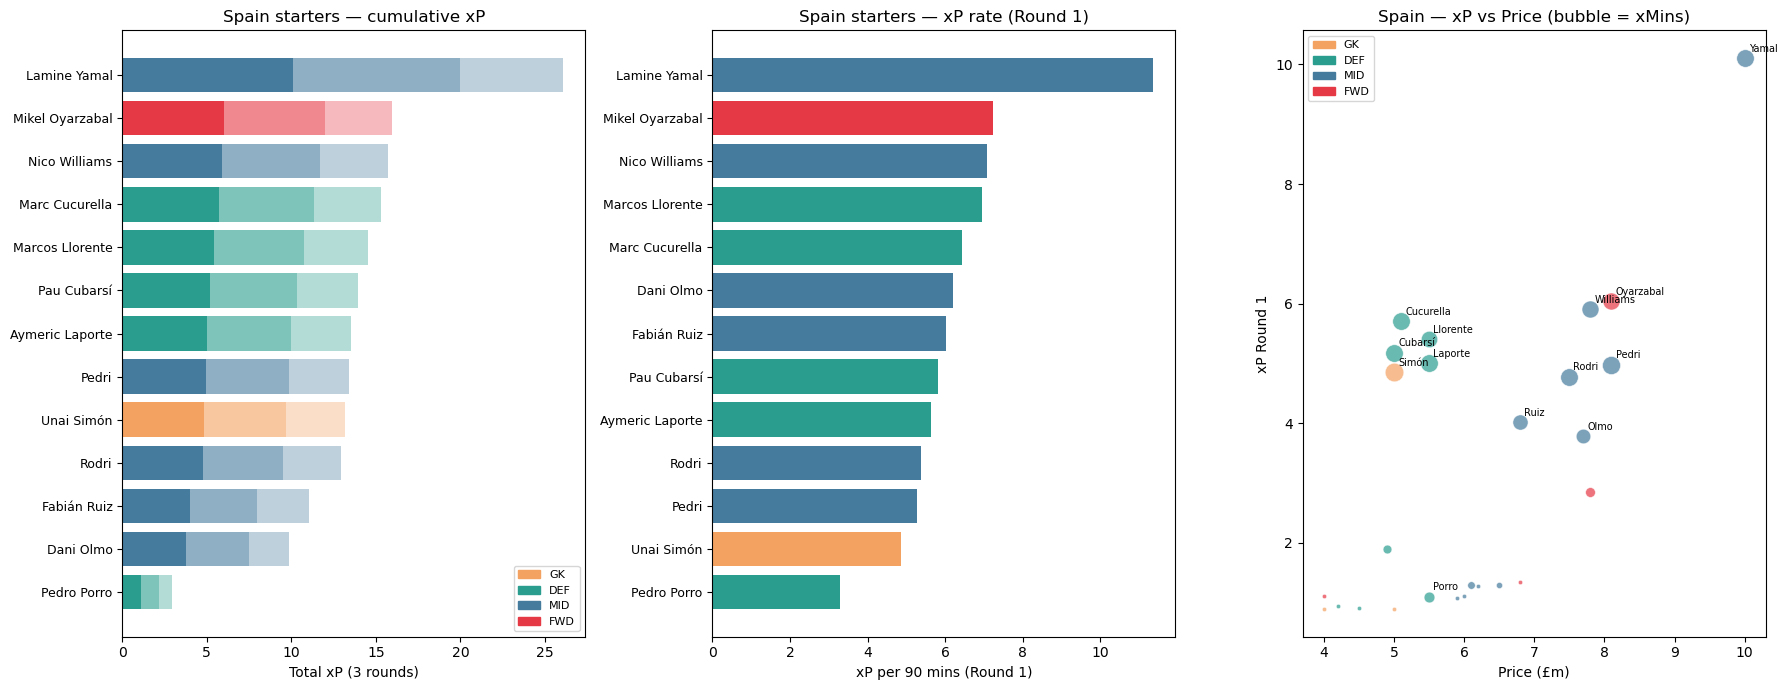

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# --- Chart 1: xP per round for starters (xmins >= 30 in round 1) ---
starters = esp[esp["1_xMins"] >= 30].sort_values("total_xpts", ascending=True)
ax = axes[0]
y = np.arange(len(starters))
bars = ax.barh(y, starters["1_Pts"], color=starters["color"], label="Round 1")
ax.barh(y, starters["2_Pts"], left=starters["1_Pts"], color=starters["color"], alpha=0.6, label="Round 2")
ax.barh(y, starters["3_Pts"], left=starters["1_Pts"] + starters["2_Pts"], color=starters["color"], alpha=0.35, label="Round 3")
ax.set_yticks(y)
ax.set_yticklabels(starters["player"], fontsize=9)
ax.set_xlabel("Total xP (3 rounds)")
ax.set_title("Spain starters — cumulative xP")
ax.axvline(0, color="black", linewidth=0.5)
legend_patches = [mpatches.Patch(color=c, label=p) for p, c in POS_COLORS.items()]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8)

# --- Chart 2: xP per 90 mins (round 1, starters only) ---
starters_sorted = starters.sort_values("xpts_per_90_r1", ascending=True)
ax = axes[1]
ax.barh(np.arange(len(starters_sorted)), starters_sorted["xpts_per_90_r1"],
        color=starters_sorted["color"])
ax.set_yticks(np.arange(len(starters_sorted)))
ax.set_yticklabels(starters_sorted["player"], fontsize=9)
ax.set_xlabel("xP per 90 mins (Round 1)")
ax.set_title("Spain starters — xP rate (Round 1)")

# --- Chart 3: xP vs Price (all players, bubble = xmins round 1) ---
ax = axes[2]
for _, row in esp.iterrows():
    ax.scatter(row["price"], row["1_Pts"], s=row["1_xMins"] * 2,
               color=row["color"], alpha=0.7, edgecolors="white", linewidth=0.5)
    if row["1_xMins"] >= 30:
        ax.annotate(row["player"].split()[-1], (row["price"], row["1_Pts"]),
                    fontsize=7, ha="left", va="bottom",
                    xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("Price (£m)")
ax.set_ylabel("xP Round 1")
ax.set_title("Spain — xP vs Price (bubble = xMins)")
legend_patches = [mpatches.Patch(color=c, label=p) for p, c in POS_COLORS.items()]
ax.legend(handles=legend_patches, fontsize=8)

plt.tight_layout()
plt.savefig("../data/spain_projections.png", dpi=150, bbox_inches="tight")
plt.show()


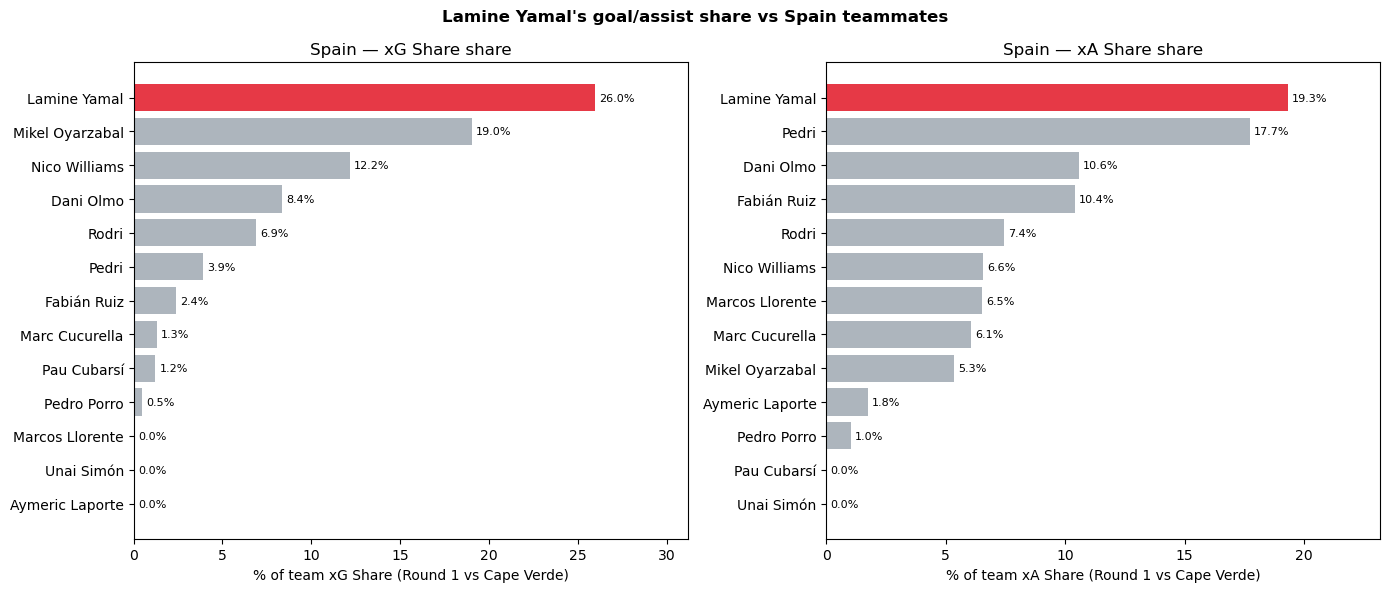

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

proj = pd.read_csv("../data/projections.csv")
esp = proj[proj["abbr"] == "ESP"].copy()

# Share of team total xG and xA for each round
for r in [1, 2, 3]:
    esp[f"{r}_xG_share"] = esp[f"{r}_xG"] / esp[f"{r}_xG"].sum()
    esp[f"{r}_xA_share"] = esp[f"{r}_xA"] / esp[f"{r}_xA"].sum()

# Focus on round 1, starters only
r1 = esp[esp["1_xMins"] >= 30].sort_values("1_xG_share", ascending=True).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ["#e63946" if p == "Lamine Yamal" else "#adb5bd" for p in r1["player"]]

for ax, metric, label in [
    (axes[0], "1_xG_share", "xG Share"),
    (axes[1], "1_xA_share", "xA Share"),
]:
    r1_sorted = r1.sort_values(metric, ascending=True)
    colors_sorted = ["#e63946" if p == "Lamine Yamal" else "#adb5bd" for p in r1_sorted["player"]]
    bars = ax.barh(r1_sorted["player"], r1_sorted[metric] * 100, color=colors_sorted)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_xlabel(f"% of team {label} (Round 1 vs Cape Verde)")
    ax.set_title(f"Spain — {label} share")
    ax.set_xlim(0, r1_sorted[metric].max() * 120)

plt.suptitle("Lamine Yamal's goal/assist share vs Spain teammates", fontweight="bold")
plt.tight_layout()
plt.show()
